In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, patheffects
from matplotlib.colors import Normalize, ListedColormap
from scipy.interpolate import griddata

In [2]:
# Load input files
# See pipeline to see how these were generated

# NMF file for 3D info
nmf = pd.read_csv('data/TP53_nmfinfo_final.csv')

# Gi* file with per residue scores, here for TEAD2
gi = pd.read_csv('data/TP53_NCOA4_gdf.csv.gz').reset_index()
gi['res'] = gi['index']+1

# Merge to create final plotting file
merged = pd.merge(nmf,gi, on='res')
merged["clust"] = merged["clust"] + 1

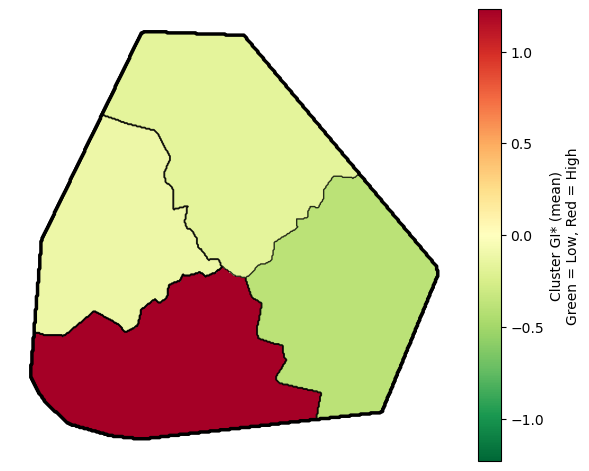

In [3]:
# Final TRN STARMAP for TP53-NCOA4

# Grid setup
xmn, xmx = merged["x_axis"].min(), merged["x_axis"].max()
ymn, ymx = merged["y_axis"].min(), merged["y_axis"].max()
pad_x = 0.05 * (xmx - xmn)
pad_y = 0.05 * (ymx - ymn)
xmn_pad, xmx_pad = xmn - pad_x, xmx + pad_x
ymn_pad, ymx_pad = ymn - pad_y, ymx + pad_y

nx, ny = 400, 400
xi = np.linspace(xmn_pad, xmx_pad, nx)
yi = np.linspace(ymn_pad, ymx_pad, ny)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate altitude and cluster grid
Zi_alt = griddata((merged["x_axis"], merged["y_axis"]),
                  merged["altitude"], (Xi, Yi), method="linear")
if isinstance(Zi_alt, np.ma.MaskedArray):
    Zi_alt = Zi_alt.filled(np.nan)
outer_mask = np.isnan(Zi_alt) | (Zi_alt <= np.nanmin(Zi_alt) + 1e-6)
inside_mask = (~outer_mask).astype(float)
Zi_alt_masked = np.ma.array(Zi_alt, mask=outer_mask)

Zi_cluster = griddata((merged["x_axis"], merged["y_axis"]),
                      merged["clust"], (Xi, Yi), method="nearest")

Zi_cluster_masked = np.ma.array(Zi_cluster, mask=outer_mask)

cluster_means = merged.groupby("clust")["Gi_sum"].mean()

# Shift the cluster ID to match (instead of 0,3 it is 1,4)
shifted_values = np.roll(cluster_means.values, -1)

cluster_means_shifted = pd.Series(
    shifted_values,
    index=cluster_means.index
)

Zi_gi_cluster = np.full_like(Zi_cluster, np.nan, dtype=float)

for clust, val in cluster_means_shifted.items():
    Zi_gi_cluster[np.isclose(Zi_cluster, clust)] = val

Zi_gi_masked = np.ma.array(Zi_gi_cluster, mask=outer_mask)

# Color scaling identical to backend
vi_max = np.nanmax(np.abs(cluster_means))
norm = Normalize(vmin=-vi_max, vmax=vi_max)
cmap = cm.RdYlGn_r

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axis("off")

# GI* field per cluster
im = ax.imshow(Zi_gi_masked, origin="lower",
               extent=(xmn_pad, xmx_pad, ymn_pad, ymx_pad),
               cmap=cmap, norm=norm, interpolation="nearest", zorder=0)

# Cluster outlines
ax.contour(Xi, Yi, Zi_cluster_masked,
           levels=np.unique(merged["clust"]),
           colors="black", linewidths=1.0, alpha=0.8, zorder=2)

# Outer border
ax.contour(Xi, Yi, inside_mask, levels=[0.5],
           colors="black", linewidths=2.5, zorder=3)

# Colorbar (backend style)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Cluster GI* (mean)\nGreen = Low, Red = High")

ax.set_xlim(xmn_pad, xmx_pad)
ax.set_ylim(ymn_pad, ymx_pad)
plt.tight_layout()
plt.show()